<a href="https://colab.research.google.com/github/anitabudhiraja/DeepLearning/blob/main/practical_4_cnn_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Techniques (DOAI250006)
## Institution: NIELIT ROPAR
## Practical 4: Image classification using CNN, 2 Convolutional layers on MNIST and CIFAR-10 dataset

This notebook demonstrates how to build a Convolutional Neural Network (CNN) with two convolutional layers to classify images. We will use the CIFAR-10 dataset, which consists of 60,000 32x32 color images in 10 classes.

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


### 1. Data Loading and Preprocessing
We will download the CIFAR-10 dataset and normalize the pixel values to be between 0 and 1. (To use MNIST instead, simply change `datasets.cifar10` to `datasets.mnist`).

In [ ]:
# Load CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

print(f'Training images shape: {train_images.shape}')
print(f'Test images shape: {test_images.shape}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training images shape: (50000, 32, 32, 3)
Test images shape: (10000, 32, 32, 3)


### 2. Building the CNN Architecture
The practical requires exactly 2 Convolutional layers. We will build a sequential model with a `Conv2D` layer, followed by a `MaxPooling2D` layer, and then repeat this once more to satisfy the 2-layer requirement. Finally, we flatten the output and pass it to Dense layers for classification.

In [ ]:
model = models.Sequential()

# First Convolutional Layer
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))

# Second Convolutional Layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Flatten and Dense layers for classification
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax')) # 10 classes in CIFAR-10

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

### 3. Compiling and Training the Model
We compile the model using the Adam optimizer and Sparse Categorical Crossentropy loss. We then train it for 10 epochs.

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 47ms/step - accuracy: 0.4835 - loss: 1.4390 - val_accuracy: 0.5955 - val_loss: 1.1550
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.6187 - loss: 1.0844 - val_accuracy: 0.6411 - val_loss: 1.0301
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.6689 - loss: 0.9488 - val_accuracy: 0.6692 - val_loss: 0.9579
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 47ms/step - accuracy: 0.7002 - loss: 0.8602 - val_accuracy: 0.6819 - val_loss: 0.9411
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 44ms/step - accuracy: 0.7262 - loss: 0.7823 - val_accuracy: 0.6857 - val_loss: 0.9213
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.7471 - loss: 0.7201 - val_accuracy: 0.6783 - val_loss: 0.9787
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.7658 - loss: 0.6689 - val_accuracy: 0.6922 - val_loss: 0.9135
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.7838 -

### 4. Evaluating the Model
Let's visualize the training progress and evaluate the final accuracy on the test set.

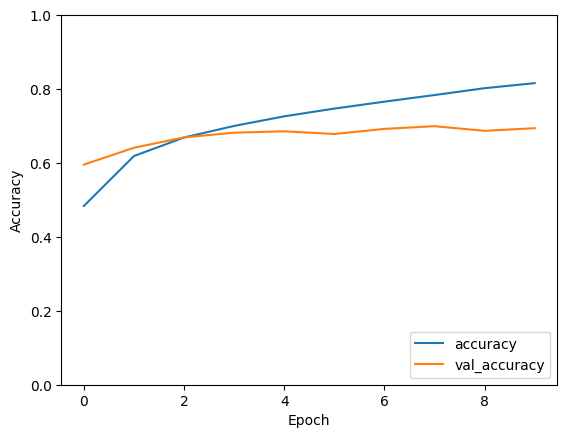

313/313 - 4s - 11ms/step - accuracy: 0.6941 - loss: 0.9980

Test Accuracy: 0.6941


In [ ]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f'\nTest Accuracy: {test_acc:.4f}')